**Homework 2**

*Instructions:* Please complete the following project and submit your solution by the next class session.

1. **Models and Regularization**
    - Recall the definitions of OLS, Ridge, and Lasso regression, and Logistic regression.
    -  How do they differ in terms of their assumptions, regularization techniques, and use cases? 
    - Provide a brief explanation for each.

2. **Dataset Analysis and Classification**

    - Load the dataset [`data/UCI_Credit_Card.csv`](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)
    
    - Rename the target variable `"default.payment.next.month"` to `"DEFAULT`"
    
    - Identify numerical vs categorical features and any variables requiring encoding or preprocessing.
    
    - Perform exploratory data analysis to understand the structure of the data. Comment on the data,identify any missing values, and visualize the relationships between features and the target variable. Briefly comment on any notable patterns or potential modeling challenges.

    - Train a LogisticRegression model to predict the default of credit card clients. Specify the train/test split strategy. Evaluate the model's performance using appropriate metrics (ROC, confusion matrix, etc). Briefly comment on any notable patterns or potential modeling challenges.
    
    - Model comparison: try at least two other classifiers from sklearn. Compare their performance with Logistic Regression. Use the same preprocessing, split, and evaluation metric for all models.

# 1. Models and Regularization

## 1) OLS 

- **Definition**: Given the linear model $y = X\beta + \varepsilon$, estimate parameters by
  $$
  \hat{\beta} = \arg\min_{\beta}\ \lVert y - X\beta \rVert_2^2.
  $$
- **Key assumptions**: The relationship is approximately linear; errors are i.i.d. with $E[\varepsilon\mid X]=0$; homoskedasticity / no autocorrelation (mainly for classical inference).
- **Regularization**: **None** (pure fit).
- **Use cases**: Strong interpretability and a standard baseline, but can be unstable / overfit under **multicollinearity** or when $p$ is large.

---

## 2) Ridge Regression

- **Definition**:
  $$
  \hat{\beta} = \arg\min_{\beta}\ \lVert y - X\beta \rVert_2^2 + \lambda \lVert \beta \rVert_2^2.
  $$
- **Assumptions**: Same linear-regression modeling framework as OLS; the penalty primarily reduces variance.
- **Regularization behavior**: **$L2$ shrinkage** pulls coefficients toward $0$, but typically **does not** set them exactly to $0$.
- **Use cases**: Prediction-focused; works well with **strong collinearity** and many features where most may carry signal.  
  Practical note: feature standardization is usually needed; choose $\lambda$ via cross-validation.

---

## 3) Lasso Regression

- **Definition**:
  $$
  \hat{\beta} = \arg\min_{\beta}\ \lVert y - X\beta \rVert_2^2 + \lambda \lVert \beta \rVert_1.
  $$
- **Assumptions**: Same linear-regression framework as OLS.
- **Regularization behavior**: **$L1$ sparsity**—many coefficients can become **exactly** $0$, effectively performing feature selection.
- **Use cases**: When you want a simpler, more interpretable model; suitable for truly **sparse** problems where only a small subset of features matters.  
  Note: under strong collinearity, Lasso often selects one feature among a correlated group and drops others; standardization is usually needed.

---

## 4) Logistic Regression (Classification Model)

- **Definition (binary classification)**:
  $$
  P(y=1\mid x)=\sigma(\beta_0 + x^\top\beta), \qquad \sigma(t)=\frac{1}{1+e^{-t}}.
  $$
  Parameters are estimated by minimizing the negative log-likelihood (cross-entropy):
  $$
  \min_{\beta}\ -\sum_i\Big[y_i\log p_i + (1-y_i)\log(1-p_i)\Big].
  $$
- **Key assumptions**: A linear relationship in the **log-odds**:
  $$
  \log\frac{p}{1-p}=\beta_0 + x^\top\beta,
  $$
  plus conditional independence of observations (typical modeling assumption).
- **Regularization**: Commonly uses **$L2$ (Ridge-type)** or **$L1$ (Lasso-type)** penalties to reduce overfitting / select features.
- **Use cases**: Classification with probabilistic outputs (threshold adjustable); robust and interpretable when the decision boundary is close to linear and features are well engineered.


In [4]:
import pandas as pd
from pathlib import Path
PATH = Path("data//UCI_Credit_Card.csv")
df = pd.read_csv(PATH)
TARGET_OLD = "default.payment.next.month"
TARGET_NEW = "DEFAULT"
df = df.rename(columns={TARGET_OLD: TARGET_NEW})
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:

TARGET = "DEFAULT"

# 1) X/y
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# 2) drop identifier
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X shape: (30000, 23)
y distribution:
 DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [6]:
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "nunique": X.nunique(dropna=True),
    "n_missing": X.isna().sum(),
})
summary["missing_rate"] = summary["n_missing"] / len(X)

summary = summary.sort_values(["dtype", "nunique"])
display(summary)

,dtype,nunique,n_missing,missing_rate
LIMIT_BAL,float64,81,0,0.0
PAY_AMT5,float64,6897,0,0.0
PAY_AMT4,float64,6937,0,0.0
PAY_AMT6,float64,6939,0,0.0
PAY_AMT3,float64,7518,0,0.0
PAY_AMT2,float64,7899,0,0.0
PAY_AMT1,float64,7943,0,0.0
BILL_AMT6,float64,20604,0,0.0
BILL_AMT5,float64,21010,0,0.0
BILL_AMT4,float64,21548,0,0.0


In [9]:

LOW_CARD_THRESHOLD = 40

low_card_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= LOW_CARD_THRESHOLD]
high_card_cols = [c for c in X.columns if c not in low_card_cols]

print(low_card_cols)

for c in low_card_cols:

    vc = X[c].value_counts(dropna=False).sort_index()
    display(vc)

['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

In [10]:
TARGET = "DEFAULT"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# remove ID (identifier)
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

nominal_cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

# Option A: treat PAY_* as categorical (recommended conservative)
cat_cols_A = nominal_cat_cols + pay_cols
num_cols_A = [c for c in X.columns if c not in cat_cols_A]

print("cat_cols_A =", cat_cols_A)
print("num_cols_A =", num_cols_A)
print("Total:", len(cat_cols_A) + len(num_cols_A), "should equal", X.shape[1])

cat_cols_A = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
num_cols_A = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Total: 23 should equal 23


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Missing in X:", X.isna().sum().sum())

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_A = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols_A),
        ("cat", categorical_pipe, cat_cols_A),
    ],
    remainder="drop"
)

Missing in X: 0


In [12]:
import numpy as np
import pandas as pd

TARGET = "DEFAULT"
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("X shape:", X.shape, "y shape:", y.shape)
print("\nTarget counts:\n", y.value_counts())
print("\nTarget rate:\n", y.value_counts(normalize=True))

X shape: (30000, 23) y shape: (30000,)

Target counts:
 DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Target rate:
 DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [13]:
num_cols = [c for c in X.columns if c not in ["SEX","EDUCATION","MARRIAGE","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]]
desc = X[num_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
display(desc)

,count,mean,std,min,1%,5%,50%,95%,99%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,10000.00,20000.0,140000.0,430000.00,500000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,22.00,23.0,34.0,53.00,60.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,-81.00,0.0,22381.5,201203.05,350110.68,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,-200.00,0.0,21200.0,194792.20,337495.28,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,-200.00,0.0,20088.5,187821.05,325030.39,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,-212.02,0.0,19052.0,174333.35,304997.27,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,-232.01,0.0,18104.5,165794.30,285868.33,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,-331.03,0.0,17071.0,161912.00,279505.06,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,0.00,0.0,2100.0,18428.20,66522.18,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,0.00,0.0,2009.0,19004.35,76651.02,1684259.0


In [14]:
corr_with_y = X[num_cols].corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top 15 |corr(feature, DEFAULT)|:")
display(corr_with_y.head(15))

Top 15 |corr(feature, DEFAULT)|:


LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
dtype: float64

In [15]:
def smd(x0, x1):
    # standardized mean difference
    m0, m1 = np.mean(x0), np.mean(x1)
    v0, v1 = np.var(x0, ddof=1), np.var(x1, ddof=1)
    return (m1 - m0) / np.sqrt((v0 + v1) / 2)

rows = []
for c in num_cols:
    x0 = X.loc[y==0, c].values
    x1 = X.loc[y==1, c].values
    rows.append({
        "feature": c,
        "mean_y0": np.mean(x0),
        "mean_y1": np.mean(x1),
        "diff(y1-y0)": np.mean(x1) - np.mean(x0),
        "SMD": smd(x0, x1),
    })

smd_df = pd.DataFrame(rows).set_index("feature")
smd_df["|SMD|"] = smd_df["SMD"].abs()
display(smd_df.sort_values("|SMD|", ascending=False).head(15))

,mean_y0,mean_y1,diff(y1-y0),SMD,|SMD|
feature,,,,,
LIMIT_BAL,178099.726074,130109.656420,-47990.069655,-0.387735,0.387735
PAY_AMT1,6307.337357,3397.044153,-2910.293204,-0.201886,0.201886
PAY_AMT2,6640.465074,3388.649638,-3251.815436,-0.164875,0.164875
PAY_AMT4,5300.529319,3155.626733,-2144.902586,-0.150951,0.150951
PAY_AMT3,5753.496833,3367.351567,-2386.145266,-0.148404,0.148404
PAY_AMT5,5248.220296,3219.139542,-2029.080754,-0.143303,0.143303
PAY_AMT6,5719.371769,3441.482068,-2277.889701,-0.139345,0.139345
BILL_AMT1,51994.227273,48509.162297,-3485.064976,-0.047300,0.047300
BILL_AMT2,49717.435670,47283.617842,-2433.817828,-0.034115,0.034115


In [16]:
cat_cols = ["SEX","EDUCATION","MARRIAGE","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

def default_rate_table(col):
    tab = pd.crosstab(X[col], y, normalize="index")  # row-wise rate
    cnt = X[col].value_counts().rename("count")
    out = tab.join(cnt)
    out.columns = ["rate_y0", "rate_y1", "count"]
    return out.sort_values("count", ascending=False)

for c in cat_cols:
    print(f"\n=== {c} default rate by category ===")
    display(default_rate_table(c))


=== SEX default rate by category ===


,rate_y0,rate_y1,count
SEX,,,
2,0.792237,0.207763,18112
1,0.758328,0.241672,11888



=== EDUCATION default rate by category ===


,rate_y0,rate_y1,count
EDUCATION,,,
2,0.762651,0.237349,14030
1,0.807652,0.192348,10585
3,0.748424,0.251576,4917
5,0.935714,0.064286,280
4,0.943089,0.056911,123
6,0.843137,0.156863,51
0,1.000000,0.000000,14



=== MARRIAGE default rate by category ===


...

,rate_y0,rate_y1,count
PAY_4,,,
0,0.816712,0.183288,16455
-1,0.841041,0.158959,5687
-2,0.807498,0.192502,4348
2,0.476733,0.523267,3159
3,0.388889,0.611111,180
4,0.333333,0.666667,69
7,0.172414,0.827586,58
5,0.485714,0.514286,35
6,0.600000,0.400000,5



=== PAY_5 default rate by category ===


,rate_y0,rate_y1,count
PAY_5,,,
0,0.811471,0.188529,16947
-1,0.838057,0.161943,5539
-2,0.803124,0.196876,4546
2,0.458111,0.541889,2626
3,0.365169,0.634831,178
4,0.392857,0.607143,84
7,0.172414,0.827586,58
5,0.411765,0.588235,17
6,0.250000,0.750000,4



=== PAY_6 default rate by category ===


,rate_y0,rate_y1,count
PAY_6,,,
0,0.811556,0.188444,16286
-1,0.830139,0.169861,5740
-2,0.799591,0.200409,4895
2,0.493492,0.506508,2766
3,0.358696,0.641304,184
4,0.367347,0.632653,49
7,0.173913,0.826087,46
6,0.263158,0.736842,19
5,0.461538,0.538462,13


/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


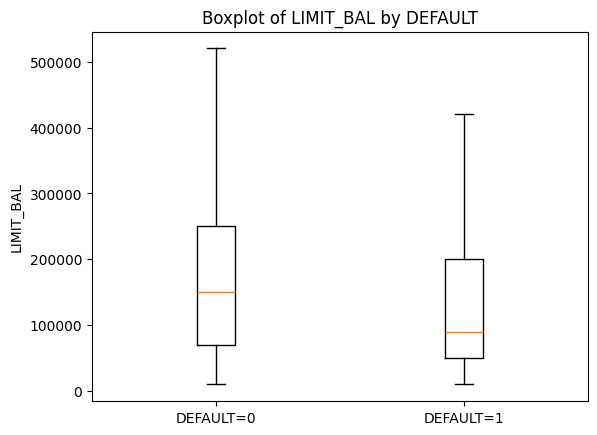

/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


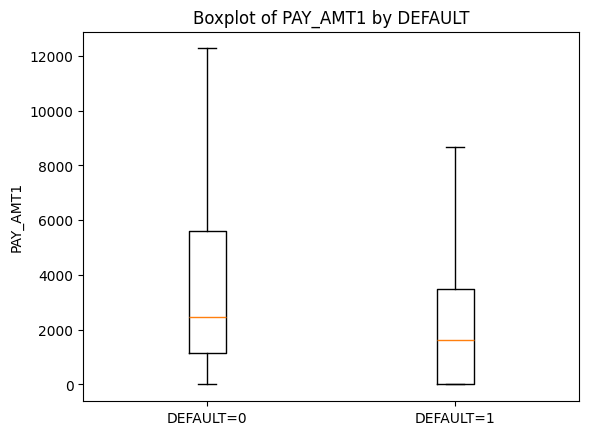

/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


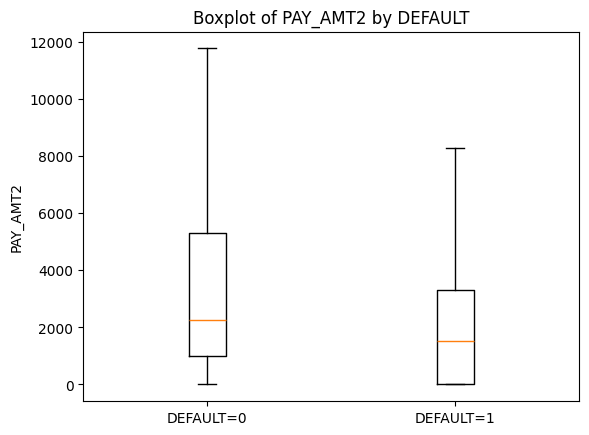

/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


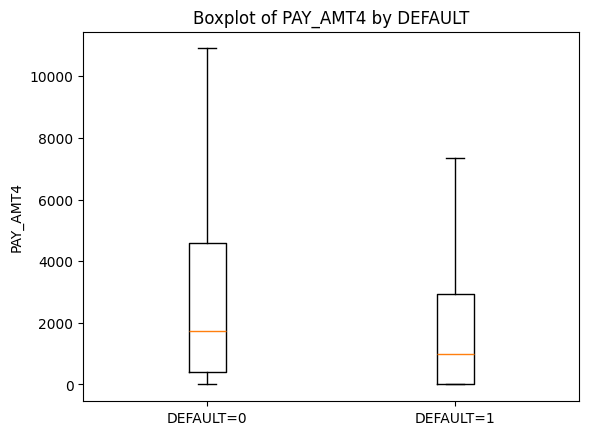

/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


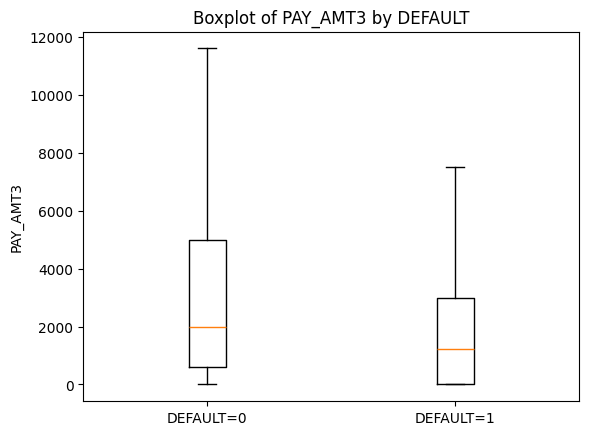

/var/folders/1w/tmj9c48j1sj2f7fr4643r88r0000gn/T/ipykernel_26380/3859866155.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)


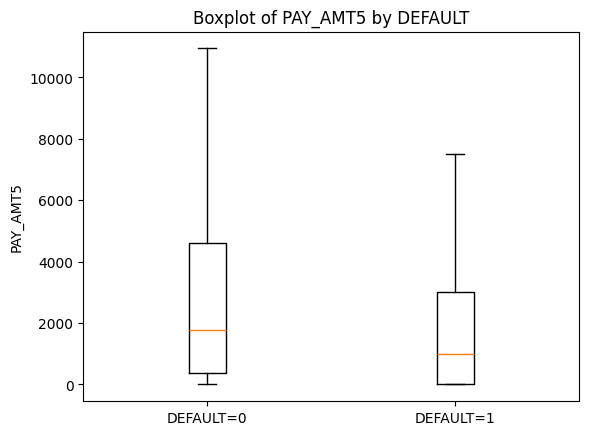

In [17]:
import matplotlib.pyplot as plt

top_num = corr_with_y.abs().head(6).index.tolist()

for c in top_num:
    data0 = X.loc[y==0, c].values
    data1 = X.loc[y==1, c].values
    plt.figure()
    plt.boxplot([data0, data1], labels=["DEFAULT=0", "DEFAULT=1"], showfliers=False)
    plt.title(f"Boxplot of {c} by DEFAULT")
    plt.ylabel(c)
    plt.show()

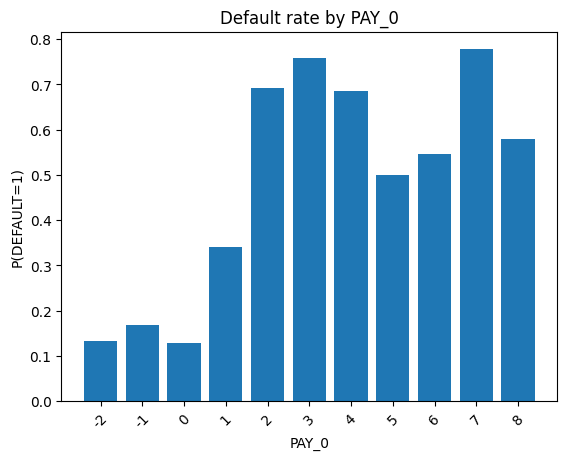

In [18]:
def plot_default_rate(col):
    rates = default_rate_table(col).sort_index()
    plt.figure()
    plt.bar(rates.index.astype(str), rates["rate_y1"].values)
    plt.title(f"Default rate by {col}")
    plt.xlabel(col)
    plt.ylabel("P(DEFAULT=1)")
    plt.xticks(rotation=45)
    plt.show()

plot_default_rate("PAY_0")

In [19]:
corr = X[num_cols].corr().abs()
# 只看上三角
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .reset_index()
         .rename(columns={"level_0":"f1","level_1":"f2",0:"abs_corr"})
)

display(high_pairs.head(20))

,f1,f2,abs_corr
0,BILL_AMT1,BILL_AMT2,0.951484
1,BILL_AMT5,BILL_AMT6,0.946197
2,BILL_AMT4,BILL_AMT5,0.940134
3,BILL_AMT2,BILL_AMT3,0.928326
4,BILL_AMT3,BILL_AMT4,0.923969
5,BILL_AMT4,BILL_AMT6,0.900941
6,BILL_AMT2,BILL_AMT4,0.892482
7,BILL_AMT1,BILL_AMT3,0.892279
8,BILL_AMT3,BILL_AMT5,0.883910
9,BILL_AMT1,BILL_AMT4,0.860272


ROC-AUC: 0.7584446299679523
PR-AUC (Average Precision): 0.5275896397780148

Confusion matrix @0.5:
 [[4437  236]
 [ 859  468]]

Classification report @0.5:
               precision    recall  f1-score   support

           0     0.8378    0.9495    0.8902      4673
           1     0.6648    0.3527    0.4609      1327

    accuracy                         0.8175      6000
   macro avg     0.7513    0.6511    0.6755      6000
weighted avg     0.7995    0.8175    0.7952      6000



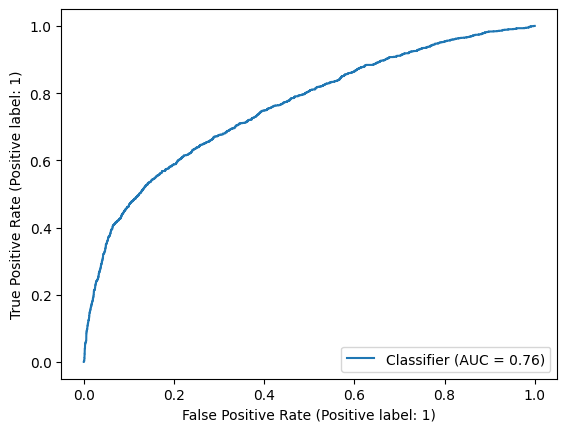

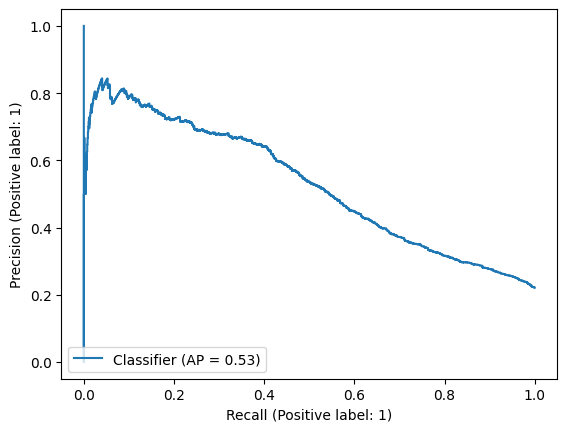

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

TARGET = "DEFAULT"

# X/y
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

# Scheme A columns
nominal_cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
cat_cols = nominal_cat_cols + pay_cols
num_cols = [c for c in X.columns if c not in cat_cols]

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocess
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# Model
logit = LogisticRegression(
    max_iter=5000,
    solver="saga",
    penalty="l2",
    C=1.0,
    random_state=42
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit)
])

# Fit
clf.fit(X_train, y_train)

# Predict scores
y_score = clf.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_score))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_score))
print("\nConfusion matrix @0.5:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report @0.5:\n", classification_report(y_test, y_pred, digits=4))

RocCurveDisplay.from_predictions(y_test, y_score)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_score)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix
)

TARGET = "DEFAULT"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

nominal_cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
cat_cols = nominal_cat_cols + pay_cols
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # 输出 dense，保证 RF/GB 能吃
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

def eval_proba_model(name, model):
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_score = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= 0.5).astype(int)

    out = {
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score),
        "accuracy@0.5": accuracy_score(y_test, y_pred),
        "precision_1@0.5": precision_score(y_test, y_pred, zero_division=0),
        "recall_1@0.5": recall_score(y_test, y_pred, zero_division=0),
        "f1_1@0.5": f1_score(y_test, y_pred, zero_division=0),
        "confusion_matrix@0.5": confusion_matrix(y_test, y_pred),
    }
    return out

results = []

# Baseline: Logistic Regression (与你 Step4 逻辑一致)
results.append(eval_proba_model(
    "LogisticRegression(L2)",
    LogisticRegression(max_iter=5000, solver="saga", penalty="l2", C=1.0, random_state=42)
))

# Model 1: Random Forest
results.append(eval_proba_model(
    "RandomForest",
    RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=10,
        class_weight="balanced_subsample"
    )
))

# Model 2: Gradient Boosting
results.append(eval_proba_model(
    "GradientBoosting",
    GradientBoostingClassifier(random_state=42)
))

res_df = pd.DataFrame(results).drop(columns=["confusion_matrix@0.5"]).sort_values("ROC_AUC", ascending=False)
display(res_df)

print("\nConfusion matrices @0.5:")
for r in results:
    print(r["model"], "\n", r["confusion_matrix@0.5"], "\n")

,model,ROC_AUC,PR_AUC,accuracy@0.5,precision_1@0.5,recall_1@0.5,f1_1@0.5
2,GradientBoosting,0.778101,0.554098,0.817333,0.663366,0.353429,0.461160
1,RandomForest,0.776234,0.553976,0.788833,0.520548,0.572720,0.545389
0,LogisticRegression(L2),0.758459,0.527546,0.817500,0.664773,0.352675,0.460857



Confusion matrices @0.5:
LogisticRegression(L2) 
 [[4437  236]
 [ 859  468]] 

RandomForest 
 [[3973  700]
 [ 567  760]] 

GradientBoosting 
 [[4435  238]
 [ 858  469]] 



## 2. Dataset Analysis and Classification (UCI Credit Card Default)

### 2.1 Load Data and Rename Target
- Loaded `data/UCI_Credit_Card.csv` with shape **(30000, 25)**.
- Renamed the target column from `default.payment.next.month` to **`DEFAULT`**.
- Target distribution:
  - `DEFAULT = 0`: **23364** (**0.7788**)
  - `DEFAULT = 1`: **6636** (**0.2212**)

---

### 2.2 Feature Types and Preprocessing Plan
- Dropped `ID` as an identifier (non-informative for prediction).
- **Categorical features (One-Hot Encoded, Scheme A):**
  - `SEX`, `EDUCATION`, `MARRIAGE`
  - `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`
- **Numerical features (impute median if needed; StandardScaler for linear models):**
  - `LIMIT_BAL`, `AGE`
  - `BILL_AMT1`–`BILL_AMT6`
  - `PAY_AMT1`–`PAY_AMT6`
- Missing values: **0** missing entries in `X` (no imputation actually needed, but the pipeline is kept for robustness).

---

### 2.3 Exploratory Data Analysis (EDA)

#### 2.3.1 Correlation with Target (Numerical Features)
Top numerical features by $|\mathrm{corr}(\text{feature}, \mathrm{DEFAULT})|$ (Pearson):
- `LIMIT_BAL`: **-0.153520**
- `PAY_AMT1`: **-0.072929**
- `PAY_AMT2`: **-0.058579**
- `PAY_AMT4`: **-0.056827**
- `PAY_AMT3`: **-0.056250**
- `PAY_AMT5`: **-0.055124**
- `PAY_AMT6`: **-0.053183**
- `BILL_AMT1`: **-0.019644** (and other `BILL_AMT*` are similarly small in magnitude)
- `AGE`: **0.013890** (very small)

Interpretation based on these values:
- `LIMIT_BAL` has the strongest linear association among numerical variables (negative correlation with default).
- `PAY_AMT*` variables show modest negative correlations with default.
- `BILL_AMT*` variables have weak linear correlations with the target.

#### 2.3.2 Multicollinearity (Numerical Features)
Strong correlations exist among bill amount variables, indicating high multicollinearity:
- $\mathrm{corr}(\text{BILL\_AMT1}, \text{BILL\_AMT2}) = 0.951484$
- $\mathrm{corr}(\text{BILL\_AMT5}, \text{BILL\_AMT6}) = 0.946197$
- $\mathrm{corr}(\text{BILL\_AMT4}, \text{BILL\_AMT5}) = 0.940134$
- $\mathrm{corr}(\text{BILL\_AMT2}, \text{BILL\_AMT3}) = 0.928326$
- $\mathrm{corr}(\text{BILL\_AMT3}, \text{BILL\_AMT4}) = 0.923969$

Modeling implication:
- Such multicollinearity can make coefficients less stable in linear models, motivating the use of regularization (e.g., $L2$).

#### 2.3.3 Default Rate by `PAY_0` Category (Example Categorical Relationship)
Default rates by category for `PAY_0` show a strong monotonic pattern for the major groups:
- `PAY_0 = 0`: $P(\mathrm{DEFAULT}=1)=0.128113$ (count 14737)
- `PAY_0 = 1`: $P(\mathrm{DEFAULT}=1)=0.339479$ (count 3688)
- `PAY_0 = 2`: $P(\mathrm{DEFAULT}=1)=0.691414$ (count 2667)

Note:
- Some high categories have very small counts (e.g., `PAY_0 = 6,7,8`), so those rates should be interpreted cautiously due to limited sample size.

#### 2.3.4 Notable Modeling Challenges
- **Class imbalance**: positive class rate is about **22.12%**, so accuracy alone can be misleading.
- **Multicollinearity** among `BILL_AMT*` variables is very strong (correlations $>0.90$ in multiple pairs).
- **Rare categories** exist in some encoded variables; performance on these levels may be noisy.

---

### 2.4 Logistic Regression Model (Baseline)

#### 2.4.1 Split Strategy
- Train/test split: **80/20**, `random_state=42`, **stratified** by `DEFAULT`.

#### 2.4.2 Performance (Test Set, Threshold = 0.5)
- **ROC-AUC**: **0.7584446**
- **PR-AUC (Average Precision)**: **0.5275896**

Confusion matrix (rows: true, cols: predicted):
\[
\begin{bmatrix}
4437 & 236\\
859 & 468
\end{bmatrix}
\]
- Accuracy: **0.8175**
- For `DEFAULT=1`:
  - Precision: **0.6648**
  - Recall: **0.3527**
  - F1: **0.4609**

Comment:
- At threshold $0.5$, the model yields relatively high precision for the default class but low recall (many false negatives), consistent with the imbalanced class distribution.

---

### 2.5 Model Comparison (Same Preprocessing, Split, and Metrics)

Models evaluated using the same preprocessing pipeline (Scheme A), same split, and the same metrics:

| Model | ROC-AUC | PR-AUC | Accuracy@0.5 | Precision(1)@0.5 | Recall(1)@0.5 | F1(1)@0.5 |
|---|---:|---:|---:|---:|---:|---:|
| GradientBoosting | 0.778101 | 0.554098 | 0.817333 | 0.663366 | 0.353429 | 0.461160 |
| RandomForest | 0.776234 | 0.553976 | 0.788833 | 0.520548 | 0.572720 | 0.545389 |
| LogisticRegression(L2) | 0.758459 | 0.527546 | 0.817500 | 0.664773 | 0.352675 | 0.460857 |

Confusion matrices (threshold $0.5$):
- LogisticRegression(L2):
\[
\begin{bmatrix}
4437 & 236\\
859 & 468
\end{bmatrix}
\]
- RandomForest:
\[
\begin{bmatrix}
3973 & 700\\
567 & 760
\end{bmatrix}
\]
- GradientBoosting:
\[
\begin{bmatrix}
4435 & 238\\
858 & 469
\end{bmatrix}
\]

Key observations:
- **GradientBoosting** achieves the best ranking performance (highest ROC-AUC and PR-AUC), but at threshold $0.5$ its precision/recall/F1 are very similar to Logistic Regression.
- **RandomForest** substantially improves default-class recall (**0.5727**) and F1 (**0.5454**) at threshold $0.5$, but with a higher false positive count and lower overall accuracy.
- Model choice depends on the objective: if capturing more defaults is critical (higher recall/F1), RandomForest is preferable; if probability ranking quality is the priority (higher AUC), GradientBoosting is slightly better.